In [1]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
wells = {
    "Hersus": "312642110063701",
    "Cotblm": "313105110074501",
    "LSP-4": "313312110082301"
}

def pull_dtgw(site):
    url = (
        "https://waterservices.usgs.gov/nwis/iv/"
        f"?sites={site}&parameterCd=72019"
        "&startDT=2006-01-01&endDT=2025-07-11&format=json"
    )
    r = requests.get(url).json()

    ts = r["value"]["timeSeries"][0]
    gw = pd.DataFrame(ts["values"][0]["value"])
    geo = ts["sourceInfo"]["geoLocation"]["geogLocation"]
    gw["date"] = pd.to_datetime(gw["dateTime"])
    gw["dtgw"] = pd.to_numeric(gw["value"])
    gw["latitude"] = geo["latitude"]
    gw["longitude"] = geo["longitude"]
    gw = gw.drop(columns = ["value", "dateTime", "qualifiers"])
    return gw

hersus = pull_dtgw(wells["Hersus"])
hersus.to_csv("../Data/GW/HersusGW.csv", index = False)

cotblm = pull_dtgw(wells["Cotblm"])
cotblm.to_csv("../Data/GW/CotblmGW.csv", index = False)

lsp4 = pull_dtgw(wells["LSP-4"])
lsp4.to_csv("../Data/GW/LSP-4GW.csv", index = False)


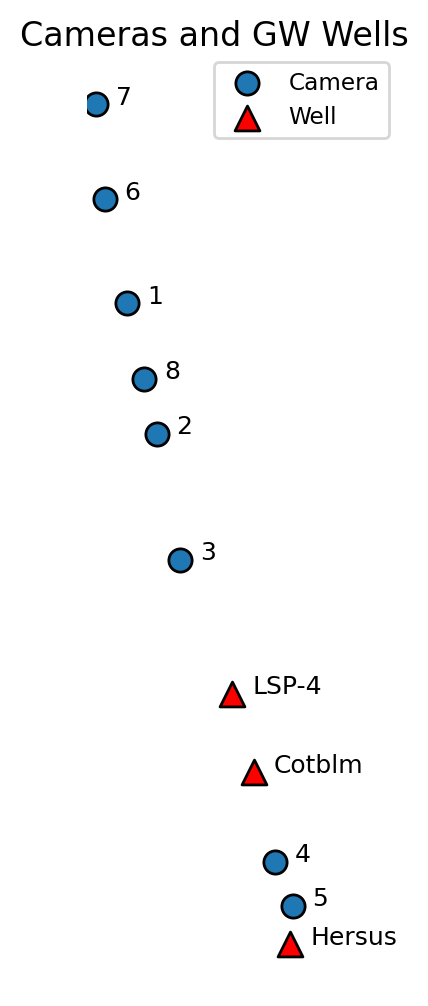

In [3]:
site_to_camera = {
    "St.David": 7,
    "Contention": 6,
    "Fairbank": 1,
    "Boquillas": 8,
    "CharlestonMesquite": 2,
    "Moson": 3,
    "Hunter": 4,
    "Hereford": 5,
}

flow = pd.read_csv(r"..\Data\USPPFlowMonitoring2006_2025.csv")

sites = (
    flow[flow["Site"].isin(site_to_camera.keys())][["Site", "Latitude", "Longitude"]]
    .drop_duplicates()
    .copy()
)
sites["Camera"] = sites["Site"].map(site_to_camera)

cameras = gpd.GeoDataFrame(
    sites,
    geometry = gpd.points_from_xy(sites["Longitude"], sites["Latitude"]),
    crs = "EPSG:4326",
)

hersus = pd.read_csv(r"..\Data\GW\HersusGW.csv")[["latitude", "longitude"]].drop_duplicates()
hersus["Site"] = "Hersus"

cotblm = pd.read_csv(r"..\Data\GW\CotblmGW.csv")[["latitude", "longitude"]].drop_duplicates()
cotblm["Site"] = "Cotblm"

lsp4 = pd.read_csv(r"..\Data\GW\LSP-4GW.csv")[["latitude", "longitude"]].drop_duplicates()
lsp4["Site"] = "LSP-4"

gw_sites = pd.concat([hersus, cotblm, lsp4], ignore_index = True).rename(columns = {"latitude": "Latitude", "longitude": "Longitude"})

gw_cameras = gpd.GeoDataFrame(
    gw_sites,
    geometry = gpd.points_from_xy(gw_sites["Longitude"], gw_sites["Latitude"]),
    crs = "EPSG:4326",
)

fig, ax = plt.subplots(figsize = (8, 6))
    
cameras.plot(
    ax = ax,
    marker = "o",
    color = "tab:blue",
    edgecolor = "black",
    markersize = 70,
    label = "Camera",
    zorder = 3,
)

gw_cameras.plot(
    ax = ax,
    marker = "^",
    color = "red",
    edgecolor = "black",
    markersize = 80,
    label = "Well",
    zorder = 2,
)

for _, row in cameras.iterrows():
    ax.text(row.geometry.x + 0.01, row.geometry.y, row["Camera"], fontsize = 9)

for _, row in gw_cameras.iterrows():
    ax.text(row.geometry.x + 0.01, row.geometry.y, row["Site"], fontsize = 9)

ax.set_title("Cameras and GW Wells")
ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] + 0.02)
ax.legend(loc = "upper left", bbox_to_anchor = (0.5, 1), fontsize = "small", borderaxespad = 0)
ax.set_axis_off()

%config InlineBackend.figure_format = "retina"

In [ ]:
daily = flow[["Date", "Site", "Latitude", "Longitude", "Flow Code"]].copy()
daily["Date"] = pd.to_datetime(daily["Date"])
daily["Camera"] = daily["Site"].map(site_to_camera)
daily["Flow Code"] = pd.to_numeric(daily["Flow Code"], errors = "coerce")
daily = (
    daily.groupby(["Date", "Site", "Camera", "Latitude", "Longitude"], as_index = False)["Flow Code"]
    .mean()
)

c4 = daily[daily["Camera"] == 4].copy()

daily_cotblm = pd.read_csv(r"..\Data\GW\CotblmGW.csv")[["date", "dtgw"]].copy()
daily_cotblm["date"] = pd.to_datetime(daily_cotblm["date"], utc = True).dt.tz_convert(None).dt.floor("D")
daily_cotblm = daily_cotblm.groupby("date", as_index = False)["dtgw"].mean()

gw = c4.merge(daily_cotblm, left_on = "Date", right_on = "date", how = "left")
gw = gw.drop(columns = ["date"])
gw["well"] = "Cotblm"

gw = gw.rename(columns={
    "Site": "site",
    "Camera": "camera",
    "Date": "date",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Flow Code": "fc",
    "dtgw": "dtgw",
})

pred = pd.read_csv(r"..\Data\PredFP.csv")[["site", "date", "fp_final", "source"]].copy()
pred["date"] = pd.to_datetime(pred["date"]).dt.floor("D")
pred = pred.rename(columns = {"fp_final": "fp"})
pred[["pred"]] = (pred[["source"]] == "predicted").astype(int)
gw = gw.merge(pred, on = ["site", "date"], how = "left")

gw = gw[["site", "camera", "date", "well", "latitude", "longitude", "fc", "dtgw", "fp", "pred"]]
gw = gw[~gw["dtgw"].isna()].copy()